# 🏆 World Cup 2026 — Match & Champion Predictor

A neural-network pipeline that predicts every remaining match of the 2026 FIFA
World Cup and simulates the tournament to a champion.

**Approach**
1. **Data** — 49k international matches (1872–2026), goalscorers, shootouts.
2. **Elo ratings** built from the full match history (team strength).
3. **Features** — Elo difference, recent form, neutral venue, match importance.
4. **Model** — a PyTorch two-headed *Poisson* network predicting expected goals
   for each side (recency- and importance-weighted training).
5. **FIFA rankings (June 2026)** and **squad strength from individual player
   ratings (EA FC 26)** blended into pre-tournament strength.
6. **Monte-Carlo simulation** of the remaining group + knockout matches → title
   odds, compared against **bookmaker odds**.

> **Players:** team strength is adjusted by the quality of each squad's actual
> players (top-23 EA ratings, depth-regularised). Change the player data and the
> predictions change — see §6.

All heavy logic lives in `src/worldcup.py`; this notebook is the narrative.

In [1]:
import sys, math
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # run from notebooks/
sys.path.insert(0, "src")                              # or from project root
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import worldcup as wc
pd.set_option("display.max_rows", 60)
print("Engine loaded. Torch:", __import__("torch").__version__)

Engine loaded. Torch: 2.7.1+cpu


## 1. Load data & quality check

In [2]:
results, shootouts, former = wc.load_data()
print("results :", results.shape)
print("shootouts:", shootouts.shape)
print("former names:", former.shape)
print("\nMissing scores:", results[['home_score','away_score']].isna().any(axis=1).sum(),
      "(all are unplayed 2026 WC fixtures)")
print("Date range:", results.date.min().date(), "->", results.date.max().date())
print("Duplicate rows:", results.duplicated().sum())

wc2026 = results[(results.date.dt.year==2026) & (results.tournament=='FIFA World Cup')]
print("\n2026 WC fixtures:", len(wc2026),
      "| already played:", wc2026.home_score.notna().sum(),
      "| remaining:", wc2026.home_score.isna().sum())
wc2026[wc2026.home_score.notna()][['date','home_team','away_team','home_score','away_score']]

results : (49477, 9)
shootouts: (678, 5)
former names: (36, 4)

Missing scores: 64 (all are unplayed 2026 WC fixtures)
Date range: 1872-11-30 -> 2026-06-27
Duplicate rows: 0

2026 WC fixtures: 72 | already played: 8 | remaining: 64


,date,home_team,away_team,home_score,away_score
49405,2026-06-11,Mexico,South Africa,2.0,0.0
49406,2026-06-11,South Korea,Czech Republic,2.0,1.0
49407,2026-06-12,Canada,Bosnia and Herzegovina,1.0,1.0
49408,2026-06-12,United States,Paraguay,4.0,1.0
49409,2026-06-13,Qatar,Switzerland,1.0,1.0
49410,2026-06-13,Brazil,Morocco,1.0,1.0
49411,2026-06-13,Haiti,Scotland,0.0,1.0
49412,2026-06-13,Australia,Turkey,2.0,0.0


## 2. Normalize team names

Historical names (e.g. *West Germany → Germany*, *Zaire → DR Congo*) are mapped
to their modern equivalents so a country's strength is continuous through time.

In [3]:
results = wc.normalize_teams(results, former)
former.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


## 3. Elo ratings from full history

A World-Football-style Elo: K-factor scaled by **match importance** (World Cup
counts more than friendlies) and **goal margin**. Home advantage is applied
unless the match is on neutral ground. We store each match's *pre-match* ratings
(model features) and the *final* ratings (simulation starting strength).

In [4]:
elo_pre, ratings = wc.compute_elo(results)
top = (pd.Series(ratings).sort_values(ascending=False).head(20)
       .rename("elo").round(0).reset_index().rename(columns={'index':'team'}))
top.index += 1
top

,team,elo
1,Spain,2130.0
2,Argentina,2109.0
3,France,2056.0
4,England,2024.0
5,Brazil,2006.0
6,Colombia,1988.0
7,Portugal,1988.0
8,Netherlands,1963.0
9,Germany,1955.0
10,Japan,1947.0


## 4. Feature engineering

Per match we build: `elo_diff` (incl. home advantage), `neutral`, `importance`,
and pre-match **rolling form** (last 10 matches' goals for / against / points)
for each side. We also cache each team's *latest* form for prediction time.

In [5]:
df, latest_form = wc.build_features(results, elo_pre)
print("Feature columns:", wc.FEATURES)
df.dropna(subset=wc.FEATURES)[['date','home_team','away_team','home_score',
    'away_score'] + wc.FEATURES].tail(6)

Feature columns: ['elo_diff', 'neutral', 'importance', 'home_form_gf', 'home_form_ga', 'home_form_pts', 'away_form_gf', 'away_form_ga', 'away_form_pts']


,date,home_team,away_team,home_score,away_score,elo_diff,neutral,importance,home_form_gf,home_form_ga,home_form_pts,away_form_gf,away_form_ga,away_form_pts
49471,2026-06-27,Algeria,Austria,NaN,NaN,10.358145,1.0,1.0,2.125,0.375,1.9,2.750,0.500,1.9
49472,2026-06-27,Jordan,Argentina,NaN,NaN,-371.028668,1.0,1.0,1.500,1.625,1.1,2.625,0.250,2.1
49473,2026-06-27,Colombia,Portugal,NaN,NaN,0.403435,1.0,1.0,2.000,0.875,1.6,2.250,0.875,1.7
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,-76.028531,1.0,1.0,1.125,0.500,1.4,1.125,1.125,0.9
49475,2026-06-27,Panama,England,NaN,NaN,-219.126993,1.0,1.0,1.750,1.625,1.2,2.125,0.250,1.9
49476,2026-06-27,Croatia,Ghana,NaN,NaN,290.958345,1.0,1.0,1.750,1.250,1.6,1.125,1.625,0.7


## 5. Train the neural network

A shared MLP trunk with two heads outputs **log expected goals** for home and
away. Trained with **Poisson negative-log-likelihood**, weighted so recent and
important matches dominate. Chronological train/validation split.

In [6]:
model, scaler, history = wc.train_model(df, epochs=60, verbose=True)
hist = pd.DataFrame(history)

epoch   0  val_poisson_nll=1.5065  outcome_acc=0.603


epoch  10  val_poisson_nll=1.4867  outcome_acc=0.606


epoch  20  val_poisson_nll=1.4834  outcome_acc=0.604


epoch  30  val_poisson_nll=1.4926  outcome_acc=0.604


epoch  40  val_poisson_nll=1.4831  outcome_acc=0.604


epoch  50  val_poisson_nll=1.4834  outcome_acc=0.605


epoch  59  val_poisson_nll=1.4871  outcome_acc=0.606


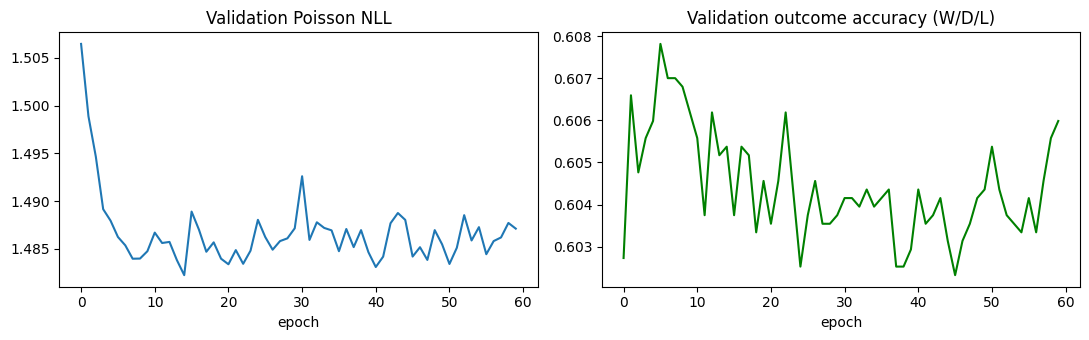

Final val outcome accuracy: 0.606
(A naive 'home/stronger team always wins' baseline sits well below this.)


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
ax[0].plot(hist.epoch, hist.val_loss); ax[0].set_title("Validation Poisson NLL")
ax[0].set_xlabel("epoch")
ax[1].plot(hist.epoch, hist.val_outcome_acc, color="green")
ax[1].set_title("Validation outcome accuracy (W/D/L)"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()
print("Final val outcome accuracy: %.3f" % hist.val_outcome_acc.iloc[-1])
print("(A naive 'home/stronger team always wins' baseline sits well below this.)")

## 6. Player ratings → squad strength, then blend into team strength

This is where **individual players matter**. From the EA FC 26 player database
(18k players) we take each nation's **top-23 players by `overall` rating**,
regularise for **depth** (thin squads get replacement-level slots), and form a
`squad_overall` index per team. Star power (`top3_overall`) and total squad
`value` are recorded too.

If you swap the player file — a new wonderkid appears, a star retires, a
different 23 are called up — these numbers move, and so do the predictions.

Neither FIFA points nor squad ratings can be *training* features (we have no
historical per-match values), so we use them the correct way: nudge each team's
results-based Elo toward its **current FIFA ranking** and **current squad
strength** (`alpha_fifa=0.20`, `alpha_squad=0.20`; 0.60 stays with history).

In [8]:
squad = wc.build_squad_strength()
print("Squad-strength index (top-23 EA ratings, depth-regularised):")
squad.head(15).reset_index(drop=True)

Squad-strength index (top-23 EA ratings, depth-regularised):


,team,n_players,squad_overall,raw_overall,top3_overall,squad_value_m
0,France,23,85.17,85.17,89.33,1452.0
1,Spain,23,84.96,84.96,89.33,1252.0
2,Brazil,23,84.04,84.04,89.00,1153.0
3,England,23,83.96,83.96,89.00,1295.5
4,Germany,23,83.83,83.83,88.67,1003.2
5,Portugal,23,83.22,83.22,87.33,960.0
6,Argentina,23,82.65,82.65,87.33,869.0
7,Netherlands,23,82.61,82.61,87.67,851.0
8,Belgium,23,81.17,81.17,87.00,664.5
9,Uruguay,23,78.91,78.91,85.00,441.6


In [9]:
# A few player squads behind the numbers
players = pd.read_csv(wc.DATA / "external/eafc26_players_raw.csv", low_memory=False)
players = players.sort_values("overall", ascending=False).drop_duplicates("player_id")
def squad_of(team, k=8):
    nat = wc.SQUAD_NAME_MAP.get(team, team)
    s = players[players.nationality_name == nat].nlargest(k, "overall")
    return s[["short_name","player_positions","overall","age","club_name"]].reset_index(drop=True)
print("Top players — France:"); display(squad_of("France"))
print("Top players — Argentina:"); display(squad_of("Argentina"))

Top players — France:


,short_name,player_positions,overall,age,club_name
0,K. Mbappé,"ST, LW, LM",91,26,Real Madrid
1,O. Dembélé,"ST, RW, CAM",90,28,Paris Saint-Germain
2,W. Saliba,CB,87,24,Arsenal
3,J. Koundé,"RB, CB, RM",87,26,FC Barcelona
4,M. Maignan,GK,87,29,AC Milan
5,M. Olise,"RM, RW",86,23,FC Bayern München
6,I. Konaté,CB,86,26,Liverpool
7,A. Griezmann,"ST, LM, CAM",85,34,Atlético Madrid


Top players — Argentina:


,short_name,player_positions,overall,age,club_name
0,L. Martínez,ST,88,27,Inter
1,A. Mac Allister,"CM, CDM",87,26,Liverpool
2,J. Alvarez,ST,87,25,Atlético Madrid
3,P. Dybala,"CAM, ST",86,31,Roma
4,L. Messi,"RW, ST, CAM, RM",86,38,Inter Miami
5,E. Martínez,GK,85,32,Aston Villa
6,E. Fernández,"CM, CDM, CAM",84,24,Chelsea
7,R. De Paul,"CM, CDM, CAM",84,31,Inter Miami


In [10]:
ratings_b = wc.blend_external_into_elo(ratings, alpha_fifa=0.20, alpha_squad=0.20)
fifa = pd.read_csv(wc.DATA / "external/fifa_rankings_2026.csv")
teams = [t for g in wc.GROUPS.values() for t in g]
comp = pd.DataFrame({"team": teams,
                     "elo_history": [round(ratings[t]) for t in teams],
                     "elo_blended": [round(ratings_b[t]) for t in teams]})
comp = comp.merge(fifa[['team','fifa_rank']], on='team', how='left')
comp = comp.merge(squad[['team','squad_overall']], on='team', how='left')
comp.sort_values("elo_blended", ascending=False).head(15).reset_index(drop=True)

,team,elo_history,elo_blended,fifa_rank,squad_overall
0,Spain,2130,2104,2,84.96
1,Argentina,2109,2083,1,82.65
2,France,2056,2060,3,85.17
3,England,2024,2028,4,83.96
4,Brazil,2006,2008,6,84.04
5,Portugal,1988,1994,5,83.22
6,Netherlands,1963,1974,8,82.61
7,Germany,1955,1971,10,83.83
8,Colombia,1988,1960,13,77.96
9,Morocco,1936,1942,7,78.83


## 7. Predict any single match

`outcome_probs` returns expected goals and Win/Draw/Loss probabilities from an
independent-Poisson goal grid. Try your own fixtures here.

In [11]:
def show_match(h, a, neutral=True):
    r = wc.outcome_probs(model, scaler, ratings_b, latest_form, h, a, neutral)
    print(f"{h} vs {a}  (neutral={neutral})")
    print(f"  expected score:  {h} {r['lambda_home']:.2f} - {r['lambda_away']:.2f} {a}")
    print(f"  P({h} win)={r['p_home']:.1%}  P(draw)={r['p_draw']:.1%}  P({a} win)={r['p_away']:.1%}\n")

show_match("Spain", "France")
show_match("Argentina", "Brazil")
show_match("United States", "England")

Spain vs France  (neutral=True)
  expected score:  Spain 1.45 - 1.01 France
  P(Spain win)=47.0%  P(draw)=26.5%  P(France win)=26.5%

Argentina vs Brazil  (neutral=True)
  expected score:  Argentina 1.56 - 0.95 Brazil
  P(Argentina win)=51.5%  P(draw)=25.5%  P(Brazil win)=23.1%

United States vs England  (neutral=True)
  expected score:  United States 0.69 - 2.07 England
  P(United States win)=11.2%  P(draw)=19.2%  P(England win)=69.6%



## 8. Predict every remaining group match

Expected score and W/D/L probabilities for all not-yet-played group fixtures.
Saved to `reports/remaining_group_predictions.csv`.

In [12]:
rem = wc2026[wc2026.home_score.isna()].copy()
rows = []
for r in rem.itertuples():
    o = wc.outcome_probs(model, scaler, ratings_b, latest_form, r.home_team, r.away_team)
    rows.append({"date": r.date.date(), "home": r.home_team, "away": r.away_team,
                 "xG_home": round(o['lambda_home'],2), "xG_away": round(o['lambda_away'],2),
                 "P_home": round(o['p_home'],3), "P_draw": round(o['p_draw'],3),
                 "P_away": round(o['p_away'],3)})
pred = pd.DataFrame(rows)
pred.to_csv(wc.ROOT / "reports/remaining_group_predictions.csv", index=False)
print("Saved", len(pred), "match predictions to reports/remaining_group_predictions.csv")
pred

Saved

 64 match predictions to reports/remaining_group_predictions.csv


,date,home,away,xG_home,xG_away,P_home,P_draw,P_away
0,2026-06-14,Germany,Curaçao,2.50,0.55,0.798,0.139,0.062
1,2026-06-14,Ivory Coast,Ecuador,0.87,1.53,0.214,0.258,0.527
2,2026-06-14,Netherlands,Japan,1.39,0.95,0.471,0.272,0.257
3,2026-06-14,Sweden,Tunisia,1.13,1.26,0.329,0.277,0.395
4,2026-06-15,Belgium,Egypt,1.69,0.76,0.596,0.239,0.165
...,...,...,...,...,...,...,...,...
59,2026-06-27,Jordan,Argentina,0.38,2.93,0.028,0.090,0.882
60,2026-06-27,Colombia,Portugal,1.09,1.28,0.313,0.277,0.409
61,2026-06-27,DR Congo,Uzbekistan,1.14,1.19,0.347,0.281,0.372
62,2026-06-27,Panama,England,0.57,2.22,0.081,0.167,0.752


## 9. Monte-Carlo tournament simulation

Simulate the remaining tournament 10,000× — sampling goals from the model's
Poisson rates, applying real group results already played, group tiebreakers,
the official 48-team bracket (12 winners + 12 runners-up + 8 best thirds), and
shootouts for knockout draws.

In [13]:
played = wc._played_group_results(results)
print("Real group results fed in:", len(played))
sim = wc.simulate_tournament(model, scaler, ratings_b, latest_form, played,
                             n_sims=10000, seed=42)
sim.to_csv(wc.ROOT / "reports/title_probabilities.csv", index=False)
sim.head(20).reset_index(drop=True)

Real group results fed in: 8


,team,win_pct,final_pct,semi_pct,quarter_pct,r16_pct,advance_pct
0,Spain,22.61,32.91,46.01,57.52,73.70,98.50
1,Argentina,17.84,28.86,42.05,55.96,68.29,97.46
2,France,12.21,20.87,36.07,53.13,74.56,94.86
3,England,10.15,18.30,31.03,48.56,70.59,96.38
4,Brazil,5.35,11.09,22.69,39.56,60.65,93.66
5,Portugal,5.16,10.88,21.26,37.67,60.44,90.51
6,Netherlands,4.57,10.12,20.78,38.28,55.82,92.98
7,Germany,3.41,8.50,19.21,35.04,64.68,94.83
8,Colombia,3.12,7.56,15.38,31.21,54.90,88.89
9,Belgium,3.05,7.72,16.02,39.88,66.66,93.31


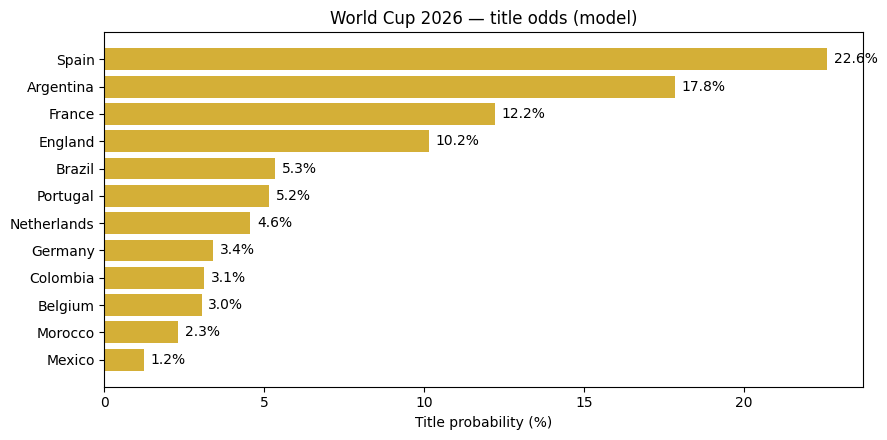

In [14]:
top12 = sim.head(12)
plt.figure(figsize=(9,4.5))
plt.barh(top12.team[::-1], top12.win_pct[::-1], color="#d4af37")
plt.xlabel("Title probability (%)"); plt.title("World Cup 2026 — title odds (model)")
for i,(t,v) in enumerate(zip(top12.team[::-1], top12.win_pct[::-1])):
    plt.text(v+0.2, i, f"{v:.1f}%", va="center")
plt.tight_layout(); plt.savefig(wc.ROOT/"reports/title_odds.png", dpi=120); plt.show()

## 10. Sanity check vs the bookmakers

Our model's title probabilities next to bookmaker / prediction-market implied
probabilities (June 12 2026). Differences are expected — bookmakers price in
squad news and sentiment; our model is strength-driven.

In [15]:
odds = pd.read_csv(wc.DATA / "external/bookmaker_odds_2026.csv")
cmp = sim[['team','win_pct']].merge(
        odds[['team','implied_prob_pct']].rename(columns={'implied_prob_pct':'market_pct'}),
        on='team', how='right')
cmp['model_pct'] = cmp['win_pct'].round(1)
cmp[['team','model_pct','market_pct']].sort_values('market_pct', ascending=False).reset_index(drop=True)

,team,model_pct,market_pct
0,Spain,22.6,17.7
1,France,12.2,17.1
2,England,10.2,11.0
3,Portugal,5.2,9.5
4,Brazil,5.4,9.0
5,Argentina,17.8,8.0
6,Germany,3.4,6.0
7,Netherlands,4.6,5.5


## 11. Most likely champion & bracket depth

Probability each top team reaches each stage.

In [16]:
stage_cols = ['advance_pct','r16_pct','quarter_pct','semi_pct','final_pct','win_pct']
view = sim.head(12).set_index('team')[stage_cols]
view.columns = ['Reach R32','Reach R16','Reach QF','Reach SF','Reach Final','Win']
view.round(1)

,Reach R32,Reach R16,Reach QF,Reach SF,Reach Final,Win
team,,,,,,
Spain,98.5,73.7,57.5,46.0,32.9,22.6
Argentina,97.5,68.3,56.0,42.0,28.9,17.8
France,94.9,74.6,53.1,36.1,20.9,12.2
England,96.4,70.6,48.6,31.0,18.3,10.2
Brazil,93.7,60.6,39.6,22.7,11.1,5.4
Portugal,90.5,60.4,37.7,21.3,10.9,5.2
Netherlands,93.0,55.8,38.3,20.8,10.1,4.6
Germany,94.8,64.7,35.0,19.2,8.5,3.4
Colombia,88.9,54.9,31.2,15.4,7.6,3.1


In [17]:
champ = sim.iloc[0]
print("="*48)
print(f"  MODEL FAVOURITE TO WIN 2026 WORLD CUP")
print(f"  >>> {champ.team}  ({champ.win_pct:.1f}% title probability) <<<")
print("="*48)
print("\nReports written to the reports/ folder:")
for f in ['title_probabilities.csv','remaining_group_predictions.csv','title_odds.png']:
    print("  -", f)

  MODEL FAVOURITE TO WIN 2026 WORLD CUP
  >>> Spain  (22.6% title probability) <<<

Reports written to the reports/ folder:
  - title_probabilities.csv
  - remaining_group_predictions.csv
  - title_odds.png


## 12. How to re-run / extend

* **More data each matchday** — as results come in, the `results.csv` is updated;
  just re-run the notebook. Already-played group games are fed in as fixed results
  and the simulation only randomises what's left.
* **Players** — `data/external/eafc26_players_raw.csv` drives squad strength;
  replace it (or edit a team's players) and re-run §6 to see predictions change.
* **Knobs** — `alpha_fifa` / `alpha_squad` (blend weights), Elo `K`/`hfa` in
  `compute_elo`, `epochs`, and `n_sims` all live in `src/worldcup.py`.
* **One-shot** — `wc.run_pipeline(n_sims=10000)` runs the whole thing headless.

> Predictions are probabilistic: even the favourite wins only ~1 time in 4. Treat
> them as odds, not certainties. ⚽